In [1]:
import os

# isort: off
import xarray as xr
import pint_xarray
import cf_xarray.units
# isort: on

import numpy as np
import pandas as pd
import seaborn as sns
from cartopy import crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes
from matplotlib import colors as mpl_colors
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from numpy.typing import ArrayLike

from pint_xarray import unit_registry as ureg
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_log_error

from utils import (
    PLASTIC_SHAPE_FACTORS,
    FIGURES_DIR,
    WhBlYlRd,
    clean_styler,
    format_units_mpl,
    load_observations,
    mass_to_particles,
    powerlaw_compute_mass,
    powerlaw_compute_number,
    spatial_integrate,
)

# Overwrite outputs
OVERWRITE = True

# Use CF unit abbreviations with negative exponents to denote units in denominator
ureg.default_format = "cf"


def save_figure(
    fig: Figure,
    filename: str,
    out_dir: str = FIGURES_DIR,
    overwrite: bool = False,
    **kwargs,
) -> None:
    """Save figure to disk

    Args:
        fig: Figure to save
        name: Filename to save to
        out_dir: Output directory (default: RESULTS_DIR)
        overwrite: Whether to overwrite existing file (default: False)
        **kwargs: Additional arguments passed to fig.savefig()
    """

    path = os.path.join(out_dir, filename)
    if os.path.exists(path) and not overwrite:
        return None

    fig.savefig(path, **kwargs)
    print(f"-> {path}")

    return None


Introduction
------------

This notebook creates figures for the paper.

Load data
---------

- Size-harmonized observations of atmospheric microplastic concentration and deposition
- Constrained simulation outputs from the *main* and *alt* simulations

In [2]:
obs_main = {
    "concentration": load_observations("obs_size-harmonized_concentration.csv"),
    "deposition": load_observations("obs_size-harmonized_deposition.csv"),
}
sim_main = xr.open_dataset("data/sim_main_constrained.nc")
sim_alt = xr.open_dataset("data/sim_alt_constrained.nc")

Figure 1
--------

Estimated global microplastic emissions from oceans (A) and land (B) to the atmosphere in this and previous studies. Leftward arrows indicate that the range of estimated emissions extends to zero. Our estimates are in black, and prior studies are in blue (ocean) and green (land), with top-down and bottom-up estimates reflected by different markers as noted in panel A. @Evangelou2026 combined elements of top-down and bottom-up approaches. Most studies used a particle size range of roughly 1-100 µm. For comparability, we adjust @Evangeliou2022’s estimates to exclude particles larger than 100 µm and show @Shaw2023's estimate for particles 0.3-70 µm. We omit @Harb2023's bottom-up estimate of 0.002 Gg yr-1 from oceans as they only considered particles smaller than 10 µm.

In [3]:
#
# Prepare emissions estimates
#

# Reported emissions
# * bu = bottom-up (process modeling); td = top-down (constrained by observations);
#   bs = bottom-up scaled to match observations
# * Brahney2021 does not report emissions from "population dust" in the text, so we use
#   18 Gg from Table 1 of Evangeliou2022. We estimate the range as 0-550 Gg based on
#   Brahney2021 Figure 4a.
# * Evangelou2022 considered a size range of 5-250 µm. For comparability, with other
#   studies, we adjust their estimates to a 5-100 µm size range based on the size
#   distribution in Table 1. We also exclude their land fiber emissions of 6500 Gg/year.
# * Brahney2021, Fu2023, and Yang2022 report only the representatitve diameters of their
#   bulk aerosol scheme, not the size bin edges. The total size range is probably roughly
#   0.1-100 µm.
# fmt: off
cols = ["Reference", "Source", "Size", "Type", "Gg/year", "low", "high"]
ests = [
    ["Brahney et al. (2021)",    "Ocean", "0.3-70 µm", "td",  8600.0,     0.0, 22000.0],
    # ["Evangeliou et al. (2022)", "Ocean", " 5-250 µm", "td",  8900.0,  5400.0, 12400.0],  # 5-250 µm
    ["Evangeliou et al. (2022)", "Ocean", " 5-100 µm", "td",  2349.0,  1425.0,  3273.0],  #  5-100 µm
    ["Yang et al. (2022)",       "Ocean", "0.3-70 µm", "bu",     0.8,     0.0,     1.5],
    ["Fu et al. (2023)",         "Ocean", "0.3-70 µm", "td",   171.0,    38.0,   764.0],
    ["Shaw et al. (2023)",       "Ocean", "   <70 µm", "bu",    20.0,    20.0,    20.0],
    ["Bucci et al. (2024)",      "Ocean", "  1-60 µm", "bu",     1.2,     0.3,     5.4],
    ["Yang et al. (2025)",       "Ocean", "0.5-70 µm", "bu",     0.8,     0.8,     0.8],
    ["Evangelou et al. (2026)",  "Ocean", " 5-100 µm", "bs",     4.0,     0.5,     8.0],
    ["Evangeliou et al. (2020)", "Land",  "   <10 µm", "bu",   434.0,   198.8,  1074.0],
    ["Brahney et al. (2021)",    "Land",  "0.3-70 µm", "td",   183.0,    63.0,  1110.0],
    # ["Evangeliou et al. (2022)", "Land",  " 5-250 µm", "td",   690.0,   388.0,   992.0],  # 5-250 µm
    ["Evangeliou et al. (2022)", "Land",  " 5-100 µm", "td",   182.0,   102.0,   262.0],  # 5-100 µm
    ["Fu et al. (2023)",         "Land",  "0.3-70 µm", "td",   154.0,    34.0,   688.0],
    ["Yang et al. (2025)",       "Land",  "0.5-70 µm", "bu", 10000.0, 10000.0, 10000.0],
    ["Evangelou et al. (2026)",  "Land",  " 5-100 µm", "bs",     0.5,     0.1,     0.9],
]
# fmt: on
emis_ests = pd.DataFrame(ests, columns=cols)

# Add our emissions estimates
emis_ours = (
    spatial_integrate(sim_main, varname="emission", sum_dims="size")
    .round(1)
    .to_dataframe("Gg/year")
    .reset_index()
    .rename(columns=lambda x: x.capitalize())
    .replace({"ocean": "Ocean", "land": "Land"})
    .assign(Reference="This study", Size="0.1-100 µm", Type="td")
)
emis_ours["low"] = emis_ours["Gg/year"]
emis_ours["high"] = emis_ours["Gg/year"]
emis_ests = (
    pd.concat([emis_ests, emis_ours], axis="index")
    .set_index(["Reference", "Source"])
    .sort_index(level=1, sort_remaining=False)
    .reset_index()
)

# Compute errorbars
emis_ests = pd.DataFrame(columns=cols, data=emis_ests)
emis_ests["err_low"] = emis_ests["Gg/year"] - emis_ests["low"]
emis_ests["err_high"] = emis_ests["high"] - emis_ests["Gg/year"]

-> figures/fig_compare-studies.jpg
-> figures/fig_compare-studies.svg


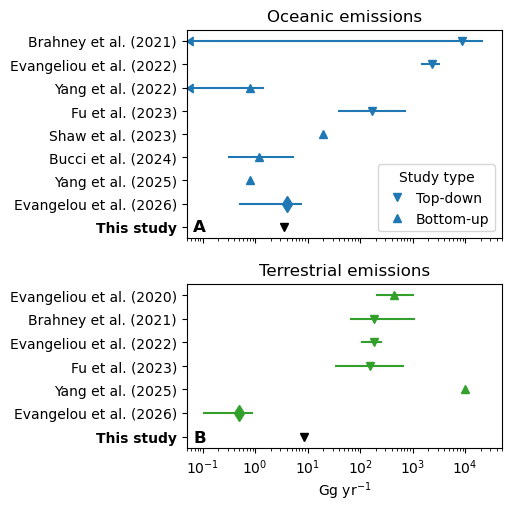

In [4]:
#
# Plot
#

# Set up figure
fig, axs = plt.subplot_mosaic(
    [["A"], ["B"]],
    figsize=(5, 5),
    gridspec_kw=dict(hspace=0.08, height_ratios=[9, 7.1]),
    layout="constrained",
)

# Common settings
xlims = (5e-2, 5e4)
ylims = {"Land": (6.5, -0.5), "Ocean": (8.5, -0.5)}
palette = {"Land": "#33a02c", "Ocean": "#1f78b4"}
marker_kws = {
    "bu": {"fmt": "^"},
    "td": {"fmt": "v"},
    "bs": {"fmt": "d", "markersize": 8},
}


def plot_estimates(data: pd.DataFrame, source: str, ax: Axes) -> None:
    """Plot emissions estmiates as points with error bars"""

    # Iterate over rows to have different markers while mainting study order
    subset = data.loc[data["Source"].eq(source)]
    for _, row in subset.iterrows():
        color = palette[source]
        if row["Reference"] == "This study":
            color = "black"

        ax.errorbar(
            x=row["Gg/year"],
            y=row["Reference"],
            xerr=[[row["err_low"]], [row["err_high"]]],
            color=color,
            elinewidth=1.5,
            label=source,
            **marker_kws[row["Type"]],
        )

        # Add left errow if estimate range extends below xaxis min
        if row["low"] < xlims[0]:
            ax.scatter(
                x=xlims[0], y=row["Reference"], marker=4, color=color, clip_on=False
            )

        # Format
        ax.set_xscale("log")
        ax.set_xlim(xlims)
        ax.set_ylim(ylims[source])
        ax.yaxis.set_inverted(True)
        title_source = {"Land": "Terrestrial", "Ocean": "Oceanic"}[source]
        ax.set_title(f"{title_source} emissions")

        # Bold label for our estimates
        for label in ax.get_yticklabels():
            if label.get_text().startswith("This study"):
                label.set_fontweight("bold")

    return None


plot_estimates(emis_ests, source="Ocean", ax=axs["A"])
plot_estimates(emis_ests, source="Land", ax=axs["B"])

axs["A"].set_xticklabels("")
axs["B"].set_xlabel(format_units_mpl("Gg yr-1"), labelpad=2)

# Legend
ax = axs["A"]
ax.legend(
    handles=[ax.lines[0], ax.lines[2]],
    labels=["Top-down", "Bottom-up"],
    title="Study type",
    loc="lower right",
    handletextpad=0.3,
)

# Label subplots
label_kws = dict(ha="left", va="bottom", fontsize=12, fontweight="bold")
for label, ax in axs.items():
    ax.text(x=0.02, y=0.02, s=label, transform=ax.transAxes, **label_kws)

save_figure(fig, filename="fig_compare-studies.jpg", dpi=200, overwrite=OVERWRITE)
save_figure(fig, filename="fig_compare-studies.svg", dpi=200, overwrite=OVERWRITE)

Emission estimates:

In [5]:
emis_est_totals = (
    emis_ests.groupby(["Reference", "Size", "Type"], as_index=False, sort=False)
    .agg(
        {
            "Source": lambda x: " ".join(x).replace("Land Ocean", "Global"),
            "Gg/year": "sum",
            "low": "sum",
            "high": "sum",
        }
    )
    .query("Source == 'Global'")
    .set_index(["Source", "Reference", "Size", "Type"])
)

clean_styler(
    pd.concat(
        [emis_ests.set_index(["Source", "Reference", "Size", "Type"]), emis_est_totals]
    )
    .drop(columns=["err_low", "err_high"])
    .style.format(precision=1)
)

Fraction of total number of particles and total mass emitted by land + oceans:

In [6]:
emis_frac = spatial_integrate(sim_main, varname="emission")
emis_frac = xr.Dataset(
    {"particles": mass_to_particles(emis_frac), "mass": emis_frac}
).to_dataframe()
emis_frac = emis_frac.groupby("source").sum() / emis_frac.sum()
emis_frac.round(3)

,particles,mass
source,,
land,0.715,0.715
ocean,0.285,0.285


Figure 2
--------

Modeling framework used to simulate atmospheric microplastic emissions, transport, and deposition with emissions following an observation-based particle size distribution and a posteriori constraint of simulation outputs to match size-harmonized atmospheric MP observations.

![flowchart](../figures/fig_flowchart.jpg)

Figure 3
--------

Framework for physically consistent comparison of atmospheric microplastic observations and model simulations. (A) Observations are usually reported as particle number size distributions as a function of particle diameter. However, microscopy-based measurements often miss smaller particles in the size range represented in atmospheric transport models. Using a database of 54 studies28, we derive a power law particle size distribution for atmospheric microplastics and extrapolate observed particle counts (dark grey bars) to the modeled size range (light grey bars). (B) We then convert size-harmonized particle counts to mass using assumptions about particle shape and density. (C) Finally, we integrate size-harmonized mass over the modeled size range to enable direct comparison with modeled mass. Panels D-G compare **Observed** atmospheric microplastic concentration and deposition over land (green) and over oceans (blue) (using study-specific size ranges, generally larger than the modeled size range) and the same data **Harmonized** to the modeled size range (0.1-100 µm) as illustrated in panels A-C. Size-harmonization increases particle counts (D, F) but decreases mass (E, G) relative to the originally reported values.

In [7]:
#
# Prepare data to illustrate harmonization method
#

edges = 2 ** np.arange(8)
low = edges[:-1]
high = edges[1:]
alpha = 2.8
c = 40

# Example data following power law size distribution with alpha = 2.8
example = pd.DataFrame(
    {
        "low": low,
        "high": high,
        "size": (low + high) / 2,
        "width": high - low,
        "count": powerlaw_compute_number(xmin=low, xmax=high, alpha=alpha, c=c),
        # Increase mass and use ng/µm3 to give values more similar to counts
        "mass": powerlaw_compute_mass(
            xmin=low,
            xmax=high,
            alpha=alpha,
            c=2 * c,
            shape_factor=PLASTIC_SHAPE_FACTORS["fragments"],
            density=ureg("g/cm3").to("ng/µm3"),
        ).magnitude,
    }
)


#
# Prepare observations
#
def compute_mass(
    path: str, number_units: str | None = None, mass_units: str | None = None
) -> pd.DataFrame:
    """Load observations and estimate mass assuming geometric midpoint size"""

    # Load, dropping any observations missing size range
    data = pd.read_csv(path).dropna()

    if "particle/m3" in data:
        number_col = "particle/m3"
        number_units = number_units or number_col
        mass_units = mass_units or "ng/m3"
    else:
        number_col = "particle/m2/d"
        number_units = number_units or "particle/m2/s"
        mass_units = mass_units or "ng/m2/s"

    # Convert number units
    number = (data[number_col].to_numpy() * ureg(number_col)).to(number_units)

    # Compute mass using geometric midpoint of size range
    # This is the method most commonly used in previous studies
    shape_factor = PLASTIC_SHAPE_FACTORS["fragments"]
    density = 1 * ureg("g/cm3")
    size = ((data["size_low"] * data["size_high"]) ** 0.5).to_numpy() * ureg("µm")
    mass = (number / ureg("particle") * size**3 * shape_factor * density).to(mass_units)

    # Collect
    data = data.assign(
        **{"type": "Observed", number_units: number.magnitude, mass_units: mass.magnitude}
    )[["study", "doi", "lat", "lon", "setting", "type", number_units, mass_units]]
    data[mass_units] = data[mass_units].replace(0, None)
    data["setting"] = data["setting"].str.title()

    return data


def load_extrapolated(
    path: str, number_units: str | None = None, mass_units: str | None = None
) -> pd.DataFrame:
    """Load and format particle counts and mass extrapolated via power law"""

    data = pd.read_csv(path)

    if "particle/m3" in data:
        number_col = "particle/m3"
        number_units = number_units or number_col
        mass_col = "ug/m3"
        mass_units = mass_units or "ng/m3"
    else:
        number_col = "particle/m2/d"
        number_units = number_units or "particle/m2/s"
        mass_col = "t/km2/yr"
        mass_units = mass_units or "ng/m2/s"

    # Convert units
    number = (data[number_col].to_numpy() * ureg(number_col)).to(number_units)
    mass = (data[mass_col].to_numpy() * ureg(mass_col)).to(mass_units)

    # Collect
    data = data.assign(
        **{
            "type": "Harmonized",
            number_units: number.magnitude,
            mass_units: mass.magnitude,
        }
    )[["study", "doi", "lat", "lon", "setting", "type", number_units, mass_units]]
    data["setting"] = data["setting"].str.title()

    return data


obs_conc = pd.concat(
    [
        compute_mass("data/obs_revised_concentration.csv"),
        load_extrapolated("data/obs_size-harmonized_concentration.csv"),
    ]
)
obs_depo = pd.concat(
    [
        compute_mass("data/obs_revised_deposition.csv"),
        load_extrapolated("data/obs_size-harmonized_deposition.csv"),
    ]
)

-> figures/fig_harmonization.jpg
-> figures/fig_harmonization.svg


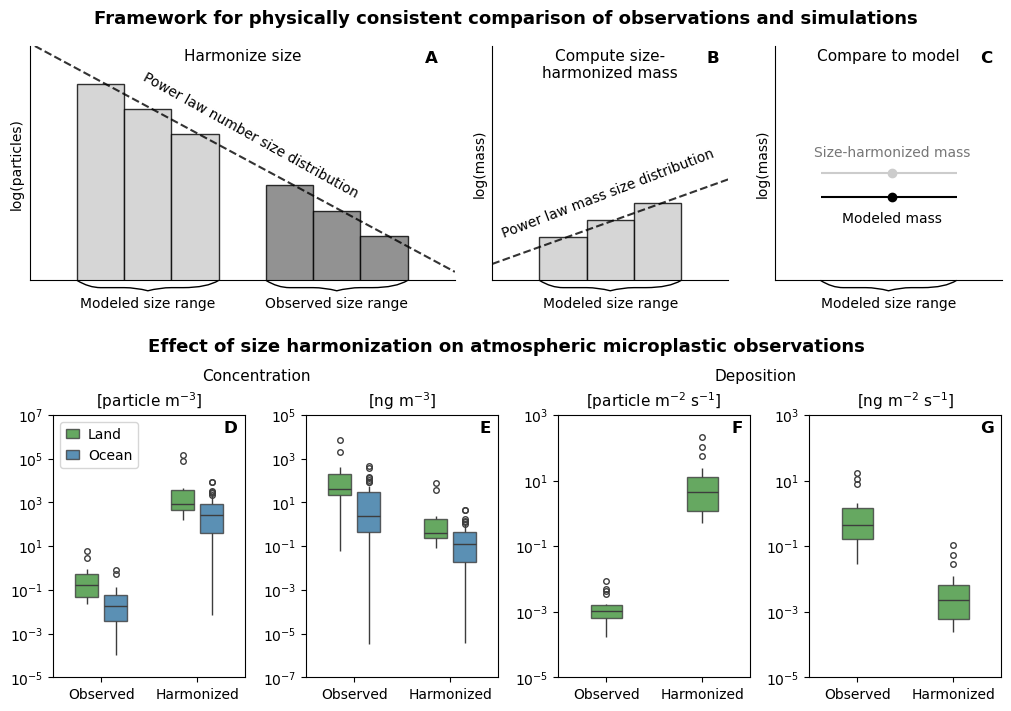

In [8]:
#
# Plot
#

# Set up figure
# * 3 rows: harmonization, spacer, boxplots
fig = plt.figure(figsize=(10, 7), layout="constrained")
grd = fig.add_gridspec(nrows=4, height_ratios=[0.03, 0.8, 0.12, 1])
row1 = GridSpecFromSubplotSpec(
    nrows=1, ncols=5, subplot_spec=grd[1], width_ratios=[9, 0.2, 5, 0.4, 4.8]
)
row2 = GridSpecFromSubplotSpec(
    nrows=2, ncols=4, subplot_spec=grd[3], height_ratios=[0.02, 1]
)
axs = {
    "A": fig.add_subplot(row1[0]),
    "B": fig.add_subplot(row1[2]),
    "C": fig.add_subplot(row1[4]),
    "D": fig.add_subplot(row2[1, 0]),
    "E": fig.add_subplot(row2[1, 1]),
    "F": fig.add_subplot(row2[1, 2]),
    "G": fig.add_subplot(row2[1, 3]),
}


def plot_harmonization(number_line_rot: float = -29, mass_line_rot: float = 21) -> None:
    """Plot the top row illustrating size harmonization"""

    #
    # Top row title
    #
    ax = fig.add_subplot(grd[0])
    ax.set_axis_off()
    ax.set_title(
        "Framework for physically consistent comparison of observations and simulations",
        fontsize=13,
        fontweight="bold",
        pad=0,
    )

    # Shared settings
    obs_color = "#777777"
    hrm_color = "#CCCCCC"
    mod_color = "black"
    bar_kws = dict(edgecolor="black", alpha=0.8)
    title_kws = dict(y=0.99, va="top", fontsize=11)

    #
    # Harmonize size
    #
    ax = axs["A"]

    # Observed number
    df = example.iloc[slice(-3, None), :]
    ax.bar(
        x=df["size"], height=df["count"], width=df["width"], color=obs_color, **bar_kws
    )

    # Harmonized number
    df = example.iloc[slice(0, 3), :]
    ax.bar(
        x=df["size"], height=df["count"], width=df["width"], color=hrm_color, **bar_kws
    )
    ax.set_ylabel("log(particles)")
    ax.set_title("Harmonize size", transform=ax.transAxes, **title_kws)

    # Powerlaw dashed line
    xy1 = example["size"].iloc[0], example["count"].iloc[0]
    xy2 = example["size"].iloc[-1], example["count"].iloc[-1]
    ax.axline(xy1=xy1, xy2=xy2, color="black", alpha=0.8, linestyle="dashed")
    ax.text(
        x=0.52,
        y=0.62,
        s="Power law number size distribution",
        rotation=number_line_rot,
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

    #
    # Compute harmonized mass
    #
    ax = axs["B"]
    ax.bar(x=df["size"], height=df["mass"], width=df["width"], color=hrm_color, **bar_kws)
    ax.set_ylabel("log(mass)")
    ax.set_title("Compute size-\nharmonized mass", transform=ax.transAxes, **title_kws)

    # Powerlaw dashed line
    xy1 = example["size"].iloc[0], example["mass"].iloc[0]
    xy2 = example["size"].iloc[-1], example["mass"].iloc[-1]
    ax.axline(xy1=xy1, xy2=xy2, color="black", alpha=0.8, linestyle="dashed")
    ax.text(
        x=0.49,
        y=0.37,
        s="Power law mass size distribution",
        rotation=mass_line_rot,
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

    #
    # Compare to model
    #
    ax = axs["C"]
    err_kws = dict(x=3, xerr=[[2], [5]], fmt="o")
    text_kws = dict(x=3, ha="center")
    ax.errorbar(y=0.2, color=hrm_color, **err_kws)
    ax.errorbar(y=0.06, color=mod_color, **err_kws)
    # Darker text for harmonized point label
    ax.text(y=0.38, s="Size-harmonized mass", color=obs_color, va="bottom", **text_kws)
    ax.text(y=0.03, s="Modeled mass", color=mod_color, va="top", **text_kws)
    ax.set_ylabel("log(mass)")
    ax.set_title("Compare to model", transform=ax.transAxes, **title_kws)


def format_harmonization(ymin: float = 1e-3, ymax: float = 1e2) -> None:
    """Format the top row illustrating size harmonization"""

    def xaxis_brackets(xmin: int, ymin: int, nbars: int = 3) -> PathPatch:
        """Helper to draw brackets indicating a range on the x-axis"""

        # Compute control points
        xmax = xmin * 2**nbars
        ctl1 = 2**0.25 * xmin
        ctl2 = 2**0.5 * xmin
        ctl3 = 2 * xmin
        ctl4 = 2**0.25 * ctl3
        xmid = 2**0.5 * ctl3
        ctl5 = 2**0.75 * ctl3
        ctl6 = xmax / 2
        ctl7 = 2**0.25 * ctl6
        ctl8 = 2**0.75 * ctl6

        # Compute heights
        y1 = 0.7 * ymin
        y2 = 0.6 * ymin

        path_data = [
            ((xmin, ymin), Path.MOVETO),
            ((ctl1, y1), Path.CURVE3),
            ((ctl2, y1), Path.CURVE3),
            ((ctl3, y1), Path.LINETO),
            ((ctl4, y1), Path.CURVE3),
            ((xmid, y2), Path.CURVE3),
            ((ctl5, y1), Path.CURVE3),
            ((ctl6, y1), Path.CURVE3),
            ((ctl7, y1), Path.LINETO),
            ((ctl8, y1), Path.CURVE3),
            ((xmax, ymin), Path.CURVE3),
        ]
        verts, codes = zip(*path_data)
        patch = PathPatch(Path(verts, codes), fill=False)
        patch.set_clip_on(False)

        return patch

    for label in ["A", "B", "C"]:
        ax = axs[label]

        # Set axis scale + limits
        ax.set_xscale("log")
        ax.set_yscale("log")
        if label == "A":
            ax.set_xlim(example["low"].min() / 2, example["high"].max() * 2)
        else:
            ax.set_xlim(example["low"].min() / 2, example["high"].iloc[2] * 2)
        ax.set_ylim(ymin, ymax)

        # Remove tick marks
        ax.xaxis.set_major_locator(plt.NullLocator())
        ax.xaxis.set_minor_locator(plt.NullLocator())
        ax.yaxis.set_major_locator(plt.NullLocator())
        ax.yaxis.set_minor_locator(plt.NullLocator())

        # Remove spines
        ax.spines[["right", "top"]].set_visible(False)

        # Add brackets highlighting size ranges
        text_kws = dict(y=0.45 * ymin, ha="center", va="top")
        ax.add_patch(xaxis_brackets(xmin=example["low"].iloc[0], ymin=ymin))
        ax.text(x=1.414 * example["low"].iloc[1], s="Modeled size range", **text_kws)
        if label == "A":
            ax.add_patch(xaxis_brackets(xmin=example["low"].iloc[4], ymin=ymin))
            ax.text(
                x=2**0.5 * example["low"].iloc[5], s="Observed size range", **text_kws
            )


def plot_boxplots(
    depo_number_units: str | None = None, depo_mass_units: str | None = None
) -> None:
    """Plot the bottom row box plots comparing observed vs. harmonized"""

    # Bottom row title
    ax = fig.add_subplot(grd[2])
    ax.set_axis_off()
    ax.set_title(
        "Effect of size harmonization on atmospheric microplastic observations",
        fontsize=13,
        fontweight="bold",
        pad=6,
        y=0,
    )

    # Common settings
    box_kws = dict(gap=0.2, fliersize=4, showcaps=False, boxprops=dict(alpha=0.8))
    title_kws = dict(y=0, va="top", fontsize=11)

    # Number concentration
    conc_kws = dict(width=0.6, hue="setting", palette=["#33a02c", "#1f78b4"])
    ax = axs["D"]
    sns.boxplot(obs_conc, x="type", y="particle/m3", ax=ax, **conc_kws, **box_kws)
    ax.set_ylim(1e-5, 1e7)

    # Mass concentration
    ax = axs["E"]
    sns.boxplot(obs_conc, x="type", y="ng/m3", ax=ax, legend=False, **conc_kws, **box_kws)
    ax.set_ylim(1e-7, 1e5)

    # Title
    ax = fig.add_subplot(row2[0, 0:2])
    ax.set_axis_off()
    ax.set_title("Concentration", **title_kws)

    # Number deposition
    depo_number_units = depo_number_units or "particle/m2/s"
    depo_kws = dict(width=0.4, color=conc_kws["palette"][0])
    ax = axs["F"]
    sns.boxplot(obs_depo, x="type", y=depo_number_units, ax=ax, **depo_kws, **box_kws)
    ax.set_ylim(1e-5, 1e3)

    # Mass deposition
    depo_mass_units = depo_mass_units or "ng/m2/s"
    ax = axs["G"]
    sns.boxplot(obs_depo, x="type", y=depo_mass_units, ax=ax, **depo_kws, **box_kws)
    ax.set_ylim(1e-5, 1e3)

    # Title
    ax = fig.add_subplot(row2[0, 2:4])
    ax.set_axis_off()
    ax.set_title("Deposition", **title_kws)


def format_boxplots() -> None:
    """Format the bottom row box plots comparing observed vs. harmonized"""

    for label in ["D", "E", "F", "G"]:
        ax = axs[label]

        units = format_units_mpl(str(ureg(ax.get_ylabel()).units))
        ax.set_title(f"[{units}]", fontsize=11)

        ax.set_yscale("log")
        ax.set_xlabel(None)
        ax.set_ylabel(None)

        if label in ["F", "G"]:
            ax.yaxis.set_major_locator(plt.LogLocator(numticks=5))
            ax.yaxis.set_minor_locator(plt.NullLocator())

        if ax.get_legend():
            ax.legend(title=None, handlelength=1, handletextpad=0.6)


def label_panels() -> None:
    """Add a label to each subplot"""

    label_kws = dict(ha="right", va="top", fontsize=12, fontweight="bold")
    for label, ax in axs.items():
        ax.text(x=0.96, y=0.98, s=label, transform=ax.transAxes, **label_kws)


plot_harmonization()
format_harmonization()
plot_boxplots()
format_boxplots()
label_panels()

# Tweak horizontal spacing of bottom row
axs["D"].set_position((0.047, 0.04, 0.1924, 0.3747))
axs["E"].set_position((0.300, 0.04, 0.1924, 0.3747))
axs["F"].set_position((0.552, 0.04, 0.1924, 0.3747))
axs["G"].set_position((0.803, 0.04, 0.1924, 0.3747))

save_figure(fig, filename="fig_harmonization.jpg", dpi=200, overwrite=OVERWRITE)
save_figure(fig, filename="fig_harmonization.svg", dpi=200, overwrite=OVERWRITE)

Observed and harmonized:

In [9]:
(
    pd.concat([obs_conc, obs_depo])
    .groupby(["setting", "type"], sort=False)[
        ["particle/m3", "ng/m3", "particle/m2/s", "ng/m2/s"]
    ]
    .median()
    .rename_axis(["variable"], axis="columns")
    .stack("variable")
    .unstack(["setting", "type"])
    .sort_index(axis="columns", level="setting", sort_remaining=False)
    .round(4)
)

setting           Land               Ocean           
type          Observed Harmonized Observed Harmonized
variable                                             
particle/m3     0.1660   840.8654   0.0180   255.1532
ng/m3          42.4757     0.4159   2.3452     0.1262
particle/m2/s   0.0011     4.4837      NaN        NaN
ng/m2/s         0.4295     0.0022      NaN        NaN

Figure 4
--------

Modeled microplastic emissions to the atmosphere (A) following an observation-based size distribution and constrained by size-harmonized observations, and the change (B) relative to a simulation using non-harmonized observations to constrain both the magnitude and size distribution of emissions (as described by @Fu2023). Both simulations model particles in the 0.1-100 µm size range using the GEOS-Chem model.

-> figures/fig_emissions.jpg
-> figures/fig_emissions.svg


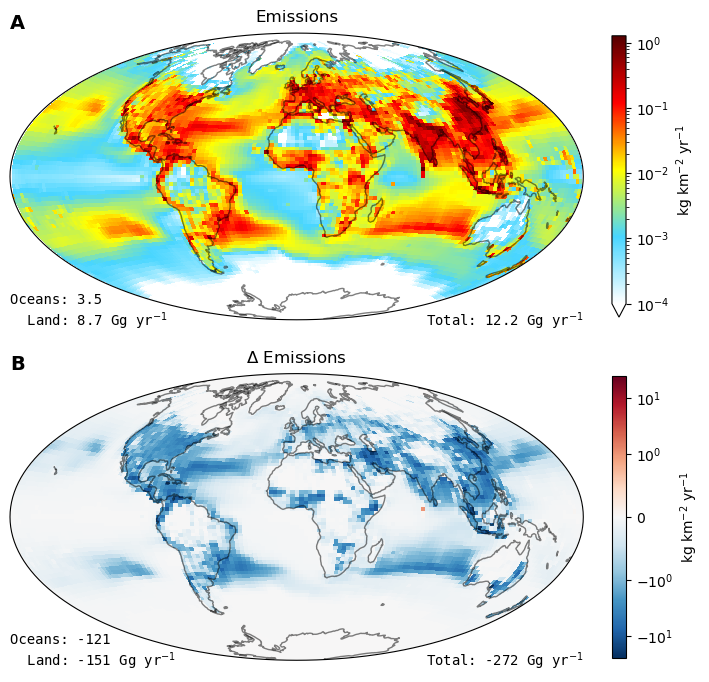

In [10]:
def plot_emissions(
    main: xr.Dataset,
    alt: xr.Dataset,
    units: str | None = "kg/km2/yr",
    cmaps: dict[str, str | mpl_colors.Colormap] | None = None,
    lims: tuple[float | None, float | None] | None = (1e-4, None),
    linthresh: float = 1,
    figsize: tuple[float, float] = (9, 9),
) -> Figure:
    """
    Plot emissions from 'main' and change compared to 'alt'

    Args:
        main: Main simulation
        alt: Alternate simulation
        units: Optional units
        cmaps: Optional dictionary of colormaps for main and delta plots
            e.g. {"main": "magma", "delta": "RdBu_r"}
        lims: Optional limit for LogNorm colorbars of main plot
        linthresh: Optional linthresh for SymLogNorm colorbar of delta plot
        figsize: Size of output figure in inches
        header_ratio: Height of column headers relative to subplot rows

    Returns:
        Figure with 2 x 1 grid of plots: main, main - alt
    """

    # Helper functions
    def annotate(ax: Axes, text: str, x: float = 0, ha: str = "left") -> None:
        font_kws = {"fontfamily": "monospace", "fontsize": 10}
        ax.text(x=x, y=-0.02, s=text, ha=ha, transform=ax.transAxes, **font_kws)

    def draw_map(
        da: xr.DataArray,
        ax: GeoAxes,
        title: str,
        cmap: str | mpl_colors.Colormap,
        norm: mpl_colors.Normalize,
    ) -> None:
        img = da.plot.imshow(
            ax=ax,
            cmap=cmap,
            add_labels=False,
            cbar_kwargs=dict(shrink=0.9),
            norm=norm,
            transform=ccrs.PlateCarree(),
        )
        ax.coastlines(alpha=0.5)
        img.colorbar.set_label(format_units_mpl(da.units))
        ax.set_title(title, va="bottom", fontsize=12)

    def plot_output(da: xr.DataArray, ax: GeoAxes, title: str) -> None:
        norm = mpl_colors.LogNorm(*lims)
        draw_map(da=da, ax=ax, title=title, cmap=cmaps["output"], norm=norm)

    def plot_delta(da: xr.DataArray, ax: GeoAxes, title: str) -> None:
        vmin = float(da.min())
        norm = mpl_colors.SymLogNorm(linthresh, vmin=vmin, vmax=-vmin)
        draw_map(da=da, ax=ax, title=title, cmap=cmaps["delta"], norm=norm)

    def plot_all(axs: dict[str, GeoAxes]) -> None:
        # Main output
        data_main = prepare_data(main, varname="emission")
        plot_output(data_main, ax=axs["A"], title="Emissions")

        # Difference vs. alt
        data_alt = prepare_data(alt, varname="emission")
        with xr.set_options(keep_attrs=True):
            delta = data_main - data_alt
        plot_delta(delta, ax=axs["B"], title="$\\Delta$ Emissions")

    def prepare_data(ds: xr.Dataset, varname: str) -> xr.DataArray:
        da = ds[varname].assign_attrs(label=ds.label)
        da = (
            da.sum(dim=["source", "size"], keep_attrs=True)
            .pint.quantify()
            .pint.to(units)
            .pint.dequantify("cf")
        )
        return da

    def write_all(axs: dict[str, Axes]) -> None:
        # Total, land and ocean emissions
        total_main = spatial_integrate(main, varname="emission", sum_dims="size")
        units = format_units_mpl(total_main.units)
        totals = total_main.to_series().round(1)
        totals_text = "\n".join(
            [
                f"Oceans: {totals['ocean']}",
                f"  Land: {totals['land']} {units}",
            ]
        )
        annotate(axs["A"], text=totals_text)
        annotate(axs["A"], text=f"Total: {totals.sum()} {units}", x=1, ha="right")

        # Delta total, land and ocean emissions
        total_alt = spatial_integrate(alt, varname="emission", sum_dims="size")
        deltas = (total_main - total_alt).to_series().round()
        deltas_text = "\n".join(
            [
                f"Oceans: {deltas['ocean']:.0f}",
                f"  Land: {deltas['land']:.0f} {units}",
            ]
        )
        annotate(axs["B"], text=deltas_text)
        annotate(axs["B"], text=f"Total: {deltas.sum():.0f} {units}", x=1, ha="right")

    # Check simulation grids
    if not (main["lat"].equals(alt["lat"]) and main["lon"].equals(alt["lon"])):
        raise NotImplementedError("main and alt have different grids")

    # Set defaults
    if cmaps is None:
        cmaps = {}
    cmaps.setdefault("output", WhBlYlRd)
    cmaps.setdefault("delta", "RdBu_r")

    # Set up figure
    fig, axs = plt.subplot_mosaic(
        [["A"], ["B"]],
        subplot_kw=dict(projection=ccrs.Hammer()),
        layout="constrained",
        figsize=figsize,
    )

    # Plot rows; add totals in bottom left corner of subplots
    plot_all(axs)
    write_all(axs)

    # Label subplots
    label_kws = dict(ha="left", va="bottom", fontsize=14, fontweight="bold")
    for label, ax in axs.items():
        ax.text(x=0, y=1, s=label, transform=ax.transAxes, **label_kws)

    return fig


fig = plot_emissions(main=sim_main, alt=sim_alt, figsize=(7, 6.8), lims=(1e-4, None))

save_figure(fig, filename="fig_emissions.jpg", dpi=200, overwrite=OVERWRITE)
save_figure(fig, filename="fig_emissions.svg", dpi=200, overwrite=OVERWRITE)

Figure 5
--------

Modeled microplastic mass concentration at the surface (A) and total mass deposition (B) compared to size-harmonized observations. R^2^ (coefficient of determination), RMSE (root mean square error), MFB (mean fractional bias), and MFE (mean fractional error) quantify the agreement between modeled and observed values. Values closer to one for R^2^ and closer to zero for the other metrics indicate better model performance. Dotted lines indicate one order of magnitude deviation from the 1:1 relationship.

-> figures/fig_scatter_main.jpg
-> figures/fig_scatter_main.svg


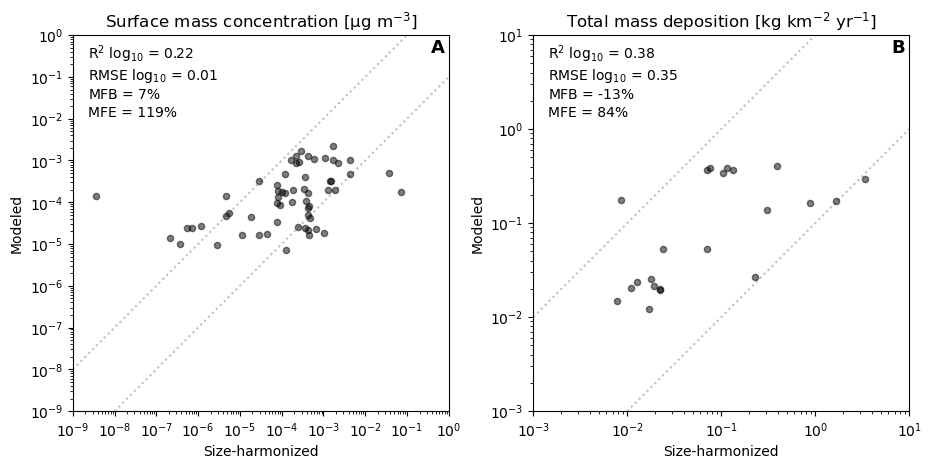

In [11]:
def mean_absolute_log_error(
    y_true: ArrayLike, y_pred: ArrayLike, sample_weight: ArrayLike | None = None
) -> float:
    """
    Return sklearn.metrics.mean_absolute_error() of log10-transformed data
    """

    y_true = np.log10(y_true)
    y_pred = np.log10(y_pred)

    return mean_absolute_error(y_true, y_pred, sample_weight=sample_weight)


def mean_fractional_bias(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    """Compute mean fractional bias

    MFB = mean(2 * (pred - true) / (pred + true))
    """

    return (2 * (y_true - y_pred) / (y_true + y_pred)).mean()


def mean_fractional_error(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    """Compute mean fractional error

    MFB = mean(2 * abs(pred - true) / (pred + true))
    """

    return (2 * np.abs(y_true - y_pred) / (y_true + y_pred)).mean()


def r2_log_score(
    y_true: ArrayLike, y_pred: ArrayLike, sample_weight: ArrayLike | None = None
) -> np.ndarray:
    """
    Return sklearn.metrics.r2_score() of log10-transformed data
    """

    y_true = np.log10(y_true)
    y_pred = np.log10(y_pred)

    return r2_score(y_true, y_pred, sample_weight=sample_weight)


def plot_sim_vs_obs(
    sim: xr.Dataset,
    obs: dict[str, xr.Dataset],
    units: dict[str, str] | None = None,
    lims: dict[str, tuple[float | None, float | None]] | None = None,
    figsize: tuple[float, float] = (9.3, 9),
    **kwargs,
) -> Figure:
    """
    Scatterplot comparing observed vs. simulated microplastics

    Args:
        sim: Dataset of scaled simulation outputs
        obs: Dictionary "concentration" and "deposition" observations
        units: Optional units for plots e.g. {"concentration": "µg/m3"}
        lims: Optional axis limits for plots e.g. {"concentration": (1e-9, 1)}
        figsize: Figure size in inches (default: (9, 5))
        **kwargs: Additional arguments passed to matplotlib.axes.Axes.scatter()
    """

    # Helper to draw a single scatterplot
    def draw_scatter(
        ax: Axes,
        sim: xr.DataArray,
        obs: xr.DataArray,
        title: str,
        units: str,
        lims: tuple[float | None, float | None],
        **kwargs,
    ) -> None:
        """Scatterplot for concentration or deposition"""

        # Get simulation outputs at observation locations and harmonize units
        obs = obs.pint.quantify().pint.to(units).pint.dequantify("cf")
        sim = (
            sim.sel(lat=obs["lat"], lon=obs["lon"], method="nearest")
            .sum(dim=["source", "size"], keep_attrs=True)
            .pint.quantify()
            .pint.to(units)
            .pint.dequantify("cf")
        )
        units = format_units_mpl(obs.units)

        # Scatterplot
        kwargs.setdefault("s", 20)
        kwargs.setdefault("c", "black")
        kwargs.setdefault("alpha", 0.5)
        kwargs.setdefault("clip_on", False)
        ax.scatter(x=obs, y=sim, **kwargs)

        # 1:10 and 10:1 lines
        ax.axline((1, 10), slope=1, color="black", alpha=0.25, linestyle=":")
        ax.axline((10, 1), slope=1, color="black", alpha=0.25, linestyle=":")

        # Format
        ax.set_xlim(*lims)
        ax.set_ylim(*lims)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Size-harmonized")
        ax.set_ylabel("Modeled")
        ax.set_title(f"{title} [{units}]")
        ax.set_aspect("equal", adjustable="box")

        # Add error metrics
        r2 = r2_log_score(y_true=obs.values, y_pred=sim.values)
        rmse = root_mean_squared_log_error(y_true=obs.values, y_pred=sim.values)
        # mae = mean_absolute_log_error(y_true=obs.values, y_pred=sim.values)
        mfb = mean_fractional_bias(y_true=obs.values, y_pred=sim.values)
        mfe = mean_fractional_error(y_true=obs.values, y_pred=sim.values)
        metrics = "\n".join(
            [
                f"R$^2$ log$_{{10}}$ = {r2:.2g}",
                f"RMSE log$_{{10}}$ = {rmse:.2g}",
                f"MFB = {mfb:.0%}$_ $",
                f"MFE = {mfe:.0%}",
            ]
        )
        ax.text(x=0.04, y=0.98, s=metrics, va="top", transform=ax.transAxes)

    # Set defaults
    if units is None:
        units = {}
    units.setdefault("concentration", "µg/m3")
    units.setdefault("deposition", "kg/km2/yr")

    if lims is None:
        lims = {}
    lims.setdefault("concentration", (1e-9, 1))
    lims.setdefault("deposition", (1e-3, 10))

    # Prepare data
    sim_conc = sim["concentration"]
    if "lev" in sim_conc.dims:
        sim_conc = sim_conc.isel(lev=0, drop=True)
    sim_depo = sim["total_deposition"]
    obs_conc = obs["concentration"]["concentration"]
    obs_depo = obs["deposition"]["deposition"]

    # Plot
    fig, axs = plt.subplot_mosaic(
        [["A", "B"]], gridspec_kw=dict(wspace=0.02), figsize=figsize, layout="constrained"
    )
    draw_scatter(
        ax=axs["A"],
        sim=sim_conc,
        obs=obs_conc,
        title="Surface mass concentration",
        units=units["concentration"],
        lims=lims["concentration"],
        **kwargs,
    )
    draw_scatter(
        ax=axs["B"],
        sim=sim_depo,
        obs=obs_depo,
        title="Total mass deposition",
        units=units["deposition"],
        lims=lims["deposition"],
        **kwargs,
    )

    # Label subplots
    label_kws = dict(ha="right", va="top", fontsize=13, fontweight="bold")
    for label, ax in axs.items():
        ax.text(x=0.99, y=0.99, s=label, transform=ax.transAxes, **label_kws)

    return fig


fig = plot_sim_vs_obs(
    sim=sim_main,
    obs=obs_main,
    lims=dict(concentration=(1e-9, 1), deposition=(1e-3, 10)),
    figsize=(9.2, 4.6),
)

save_figure(fig, filename="fig_scatter_main.jpg", dpi=200, overwrite=OVERWRITE)
save_figure(fig, filename="fig_scatter_main.svg", dpi=200, overwrite=OVERWRITE)

Miscellaneous
-------------

### Atmospheric burden

In [12]:
burden = spatial_integrate(sim_main, varname="concentration", sum_dims="size")
burden = burden.to_dataframe(f"Atmospheric burden [{burden.units}]")
burden.loc["total", :] = burden.sum()
burden.round(4)

,Atmospheric burden [Gg]
source,
ocean,0.0065
land,0.0325
total,0.0390


### Deposition over land and oceans

In [13]:
# Compute fraction of each grid cell that is ocean/land
ocean_frac = xr.open_dataset("data/MERRA2.20150101.CN.2x25.nc4")["FROCEAN"].isel(
    time=0, drop=True
)
ocean_frac["lat"] = sim_main["lat"]
ocean_frac = ocean_frac.to_dataframe()
ocean_frac["FRLAND"] = 1 - ocean_frac["FROCEAN"]

# Join optimized total deposition (obs-size-dist simulation)
depo = (
    (
        sim_main["total_deposition"].pint.quantify().sum(dim="size")
        * sim_main["area"].pint.quantify()
    )
    .rename("total_deposition")
    .pint.to("Gg/year")
    .pint.dequantify()
    .to_dataframe()
    .join(ocean_frac)
)

# Compute deposition over land vs. oceans for each emissions source
(
    pd.concat(
        [depo["total_deposition"] * depo[x] for x in ["FROCEAN", "FRLAND"]],
        axis="columns",
        keys=["depo_on_ocean", "depo_on_land"],
    )
    .groupby("source")
    .sum()
    .round(1)
)

,depo_on_ocean,depo_on_land
source,,
land,2.6,6.1
ocean,3.3,0.2
